In [1]:
!pip install face-recognition

  error: subprocess-exited-with-error
  
  python setup.py bdist_wheel did not run successfully.
  exit code: 1
  
  [47 lines of output]
  C:\Users\Asus\AppData\Local\Temp\pip-install-ws0s9bw7\dlib_f0729565b96f4efcb1549f680944b2f5\setup.py:234: SyntaxWarning: invalid escape sequence '\('
    major = re.findall("set\(CPACK_PACKAGE_VERSION_MAJOR.*\"(.*)\"", open(cmake_file).read())[0]
  C:\Users\Asus\AppData\Local\Temp\pip-install-ws0s9bw7\dlib_f0729565b96f4efcb1549f680944b2f5\setup.py:235: SyntaxWarning: invalid escape sequence '\('
    minor = re.findall("set\(CPACK_PACKAGE_VERSION_MINOR.*\"(.*)\"", open(cmake_file).read())[0]
  C:\Users\Asus\AppData\Local\Temp\pip-install-ws0s9bw7\dlib_f0729565b96f4efcb1549f680944b2f5\setup.py:236: SyntaxWarning: invalid escape sequence '\('
    patch = re.findall("set\(CPACK_PACKAGE_VERSION_PATCH.*\"(.*)\"", open(cmake_file).read())[0]
  running bdist_wheel
  running build
  running build_ext
  
  
                     CMake is not installed on your


  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached face_recognition_models-0.3.0-py2.py3-none-any.whl
  Using cached dlib-19.24.6.tar.gz (3.4 MB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)
  Running setup.py clean for dlib
Failed to build dlib


In [2]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [3]:
import cv2
import numpy as np
import os

# Load the Haar Cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Set the directory where the images for training are stored
dataset_path = 'dataset/'  # Directory containing the images
if not os.path.exists(dataset_path):
    os.makedirs(dataset_path)

# Face recognizer using the LBPH (Local Binary Patterns Histograms) recognizer
face_recognizer = cv2.face.LBPHFaceRecognizer_create()

# Function to get face data and labels
def get_images_and_labels(path):
    face_samples = []
    ids = []

    # Get all image paths
    image_paths = [os.path.join(path, f) for f in os.listdir(path)]
    
    # Loop over the image paths
    for image_path in image_paths:
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            continue

        # Convert to grayscale and detect faces
        faces = face_cascade.detectMultiScale(img, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        
        for (x, y, w, h) in faces:
            face_samples.append(img[y:y + h, x:x + w])
            id = int(os.path.split(image_path)[-1].split('.')[1])
            ids.append(id)
    
    return face_samples, ids

# Train the face recognizer with the dataset
faces, ids = get_images_and_labels(dataset_path)
face_recognizer.train(faces, np.array(ids))

print("[INFO] Training completed.")

# Save the trained model
face_recognizer.save('trainer.yml')

# Face recognition from live video stream
def recognize_face():
    cap = cv2.VideoCapture(0)  # Start video capture (webcam)
    
    face_recognizer.read('trainer.yml')  # Load trained recognizer model
    
    while True:
        ret, frame = cap.read()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # Detect faces in the frame
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
        
        for (x, y, w, h) in faces:
            face_id, confidence = face_recognizer.predict(gray[y:y + h, x:x + w])
            
            # Confidence is the distance between the known and predicted face
            confidence_text = f"Confidence: {100 - int(confidence)}%"
            
            # Draw rectangle around the face and display confidence
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.putText(frame, f"ID: {face_id} {confidence_text}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
        
        cv2.imshow('Face Recognition', frame)
        
        # Break loop on pressing 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

recognize_face()


AttributeError: module 'cv2' has no attribute 'face'

In [4]:
pip install opencv-contrib-python


   ---------------------------------------- 0.0/45.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/45.5 MB ? eta -:--:--
   ---------------------------------------- 0.2/45.5 MB 2.8 MB/s eta 0:00:17
    --------------------------------------- 1.1/45.5 MB 10.1 MB/s eta 0:00:05
   -- ------------------------------------- 2.4/45.5 MB 14.0 MB/s eta 0:00:04
   --- ------------------------------------ 3.6/45.5 MB 16.5 MB/s eta 0:00:03
   ---- ----------------------------------- 4.9/45.5 MB 18.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.9/45.5 MB 19.0 MB/s eta 0:00:03
   ------ --------------------------------- 7.1/45.5 MB 19.7 MB/s eta 0:00:02
   ------- -------------------------------- 8.2/45.5 MB 20.1 MB/s eta 0:00:02
   -------- ------------------------------- 9.3/45.5 MB 20.4 MB/s eta 0:00:02
   --------- ------------------------------ 10.3/45.5 MB 22.6 MB/s eta 0:00:02
   --------- ------------------------------ 11.2/45.5 MB 24.2 MB/s eta 0:00:02
 

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'E:\\Anaconda\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [5]:
import cv2

# Load the pre-trained face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load the trained recognizer model
face_recognizer = cv2.face.LBPHFaceRecognizer_create()
face_recognizer.read('face_trainer.yml')

# Start video capture (webcam)
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    for (x, y, w, h) in faces:
        face_id, confidence = face_recognizer.predict(gray[y:y + h, x:x + w])

        confidence_text = f"Confidence: {100 - int(confidence)}%"

        # Draw a rectangle around the face and display the ID and confidence
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(frame, f"ID: {face_id} {confidence_text}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    # Show the video feed
    cv2.imshow("Face Recognition", frame)

    # Press 'q' to exit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close all windows
cap.release()
cv2.destroyAllWindows()


AttributeError: module 'cv2' has no attribute 'face'

In [6]:
import cv2

# Load the pre-trained Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load the input image
image = cv2.imread('path_to_your_image.jpg')

# Convert the image to grayscale (Haar Cascade works with grayscale images)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces in the image
faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Draw rectangles around the detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

# Display the output image with faces highlighted
cv2.imshow('Detected Faces', image)

# Wait for a key press and close the display window
cv2.waitKey(0)
cv2.destroyAllWindows()


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [7]:
print("Image Path:", 'path_to_your_image.jpg')


Image Path: path_to_your_image.jpg


In [8]:
image = cv2.imread('C:/Users/YourUsername/ProjectFolder/image.jpg')


In [9]:
import os
if os.path.exists('path_to_your_image.jpg'):
    print("Image found")
else:
    print("Image not found")


Image not found


In [10]:
import cv2
import os

# Load the pre-trained Haar Cascade face detection model
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Provide the correct image path
image_path = 'path_to_your_image.jpg'

# Check if the image exists
if not os.path.exists(image_path):
    print(f"Error: Image '{image_path}' not found.")
else:
    # Load the input image
    image = cv2.imread(image_path)

    # Convert the image to grayscale (Haar Cascade works with grayscale images)
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw rectangles around the detected faces
    for (x, y, w, h) in faces:
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Display the output image with faces highlighted
    cv2.imshow('Detected Faces', image)

    # Wait for a key press and close the display window
    cv2.waitKey(0)
    cv2.destroyAllWindows()


Error: Image 'path_to_your_image.jpg' not found.


In [1]:
import cv2

# Load the pre-trained Haar Cascade classifier for face detection
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Start video capture from the webcam (use 0 for default camera)
cap = cv2.VideoCapture(0)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # Convert the frame to grayscale (Haar Cascade works with grayscale images)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw a rectangle around each face
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Display the resulting frame
    cv2.imshow('Face Detection', frame)

    # Break the loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\objdetect\src\cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'cv::CascadeClassifier::detectMultiScale'


In [2]:
face_cascade = cv2.CascadeClassifier('C:/path/to/haarcascade_frontalface_default.xml')


In [ ]:
!pip uninstall opencv-python
!pip install opencv-python


In [1]:
import cv2

# Load the pre-trained Haar Cascade classifier for face detection
# Replace 'C:/path/to/' with the actual path to your haarcascade_frontalface_default.xml
face_cascade = cv2.CascadeClassifier('C:/path/to/haarcascade_frontalface_default.xml')

# Start video capture from the webcam (use 0 for default camera)
cap = cv2.VideoCapture(0)

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()

    # Check if the frame is captured properly
    if not ret:
        print("Failed to grab frame")
        break

    # Convert the frame to grayscale (Haar Cascade works with grayscale images)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    # Draw a rectangle around each face
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    # Display the resulting frame
    cv2.imshow('Face Detection', frame)

    # Break the loop on 'q' key press
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close windows
cap.release()
cv2.destroyAllWindows()


error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\objdetect\src\cascadedetect.cpp:1689: error: (-215:Assertion failed) !empty() in function 'cv::CascadeClassifier::detectMultiScale'


In [2]:
import os

# Check if the Haar Cascade file exists
if not os.path.exists('haarcascade_frontalface_default.xml'):
    print("Haar Cascade file not found. Please check the file path.")


Haar Cascade file not found. Please check the file path.


In [1]:
!pip install opencv-python


In [2]:
!pip install opencv-python

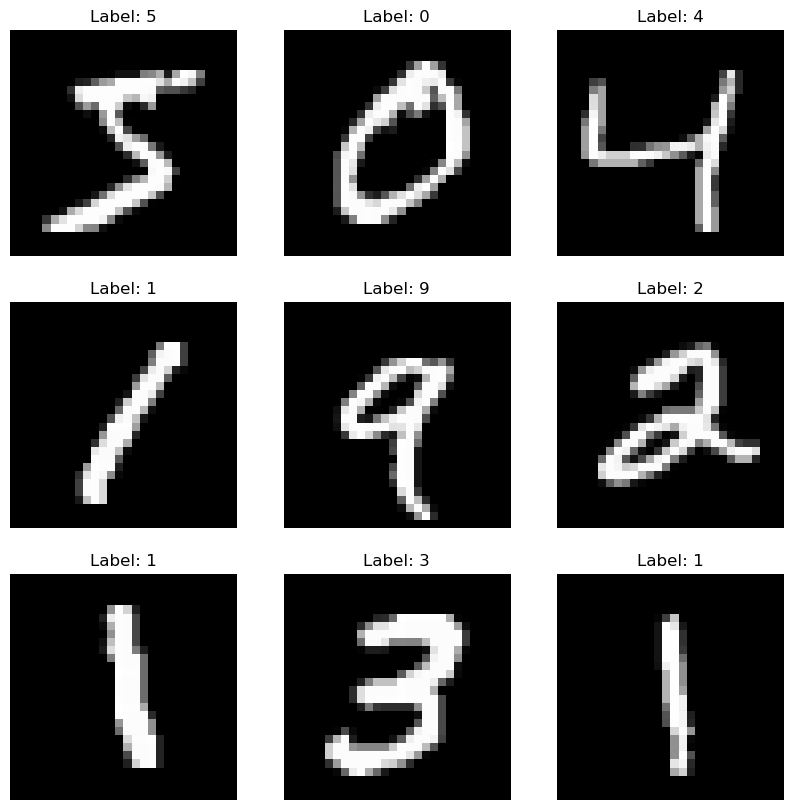

E:\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9033 - loss: 0.3169 - val_accuracy: 0.9852 - val_loss: 0.0436
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9846 - loss: 0.0494 - val_accuracy: 0.9873 - val_loss: 0.0389
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9903 - loss: 0.0320 - val_accuracy: 0.9896 - val_loss: 0.0355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9927 - loss: 0.0231 - val_accuracy: 0.9879 - val_loss: 0.0370
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9913 - val_loss: 0.0298
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9953 - loss: 0.0137 - val_accuracy: 0.9905 - val_loss: 0.0306
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9964 - loss: 0.0102 - val_accuracy: 0.9909 - val_loss: 0.0337
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9981 - loss: 0

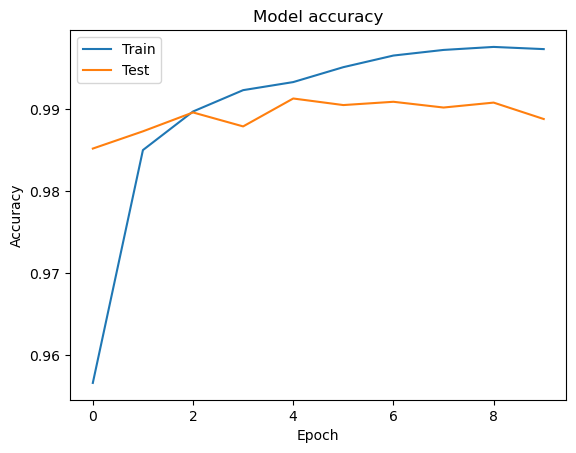

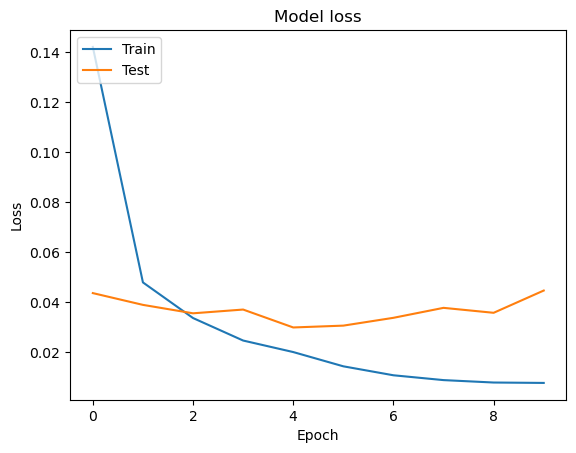

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# Step 1: Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Step 2: Normalize the pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Step 3: Reshape the data to include the channel dimension
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# Step 4: Visualizing some images from the dataset
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

# Step 5: Build the model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 classes for digits 0-9
])

# Step 6: Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 7: Train the model for 10 epochs
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# Step 8: Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print('\nTest accuracy:', test_acc)

# Step 9: Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Step 10: Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
